# Exercise 1 — Data Mining vs Machine Learning

What you will learn here:

* distinguish data vs labels
* think about problem formulation
* connect real data → ML type
* understand when ML is needed

In [67]:
# If needed:
# !pip install datasets pandas matplotlib scikit-learn librosa

In [68]:
from datasets import load_dataset
import pandas as pd

Load a small sample from the `ag_news` dataset and is a collection of more than 1 million news articles.

In [69]:
dataset = load_dataset("ag_news", split="train[:200]")

df = dataset.to_pandas()
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


### Understand the dataset

In [70]:
df.columns

Index(['text', 'label'], dtype='object')

In [71]:
df[["text", "label"]].head(10)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


## Question
What are the columns?

- Which column is the input data?
- Which column is the label?

The "text" column is the input data
The "label" column is the label

# Part A — Data Mining: Discover patterns

For this step, you cannot use the `label` column. :)

### Text length

In [72]:
df["text_length"] = df["text"].apply(len)

df[["text", "text_length"]].head()

,text,text_length
0,Wall St. Bears Claw Back Into the Black (Reute...,144
1,Carlyle Looks Toward Commercial Aerospace (Reu...,266
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,232
3,Iraq Halts Oil Exports from Main Southern Pipe...,256
4,"Oil prices soar to all-time record, posing new...",234


### Average text length

In [73]:
df["text_length"].mean()

277.225

### Most frequent words

In [74]:
from collections import Counter
import re

all_text = " ".join(df["text"].tolist()).lower()
words = re.findall(r"\b[a-z]{4,}\b", all_text)

word_counts = Counter(words)
word_counts.most_common(20)

[('that', 86),
 ('space', 54),
 ('with', 42),
 ('reuters', 40),
 ('this', 38),
 ('from', 34),
 ('they', 34),
 ('have', 33),
 ('said', 29),
 ('about', 23),
 ('more', 23),
 ('their', 19),
 ('scientists', 19),
 ('what', 19),
 ('would', 19),
 ('over', 18),
 ('after', 18),
 ('could', 18),
 ('time', 17),
 ('company', 17)]

## Reflection

Are we predicting something here?

Or are we discovering patterns already present in the data?

We are discovering patterns that already exist in the data, because what we are doing here is just simply counts the occurences of words in the given data. We are not having new data here.

# Part B — Machine Learning: Use labels

### Inspect labels

In [75]:
df["label"].value_counts()

label
3    122
2     78
Name: count, dtype: int64

### AG News labels are numeric. Add names:
from https://huggingface.co/datasets/sh0416/ag_news 

1: World 2: Sports 3: Business 4: Sci/Tech

In [76]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

df["label_name"] = df["label"].map(label_names)
df[["text", "label", "label_name"]].head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## Question

What type of ML can we apply for this dataset?

In [ ]:
We can use classification of supervised learning to classify the type of article from its header

# Part C — Explore a Dataset

In this exercise, you will:

1. Choose a dataset
2. Explore it (Data Mining)
3. Decide whether labels exist
4. Suggest a Machine Learning approach (if applicable)

You should NOT focus on complex models.
Focus on understanding the problem.

## Step 1 — Choose a dataset

* Hugging Face datasets: https://huggingface.co/datasets
* Scikit-learn datasets: https://scikit-learn.org/stable/datasets/toy_dataset.html

Dataset examples:

In [7]:
from datasets import load_dataset
dataset = load_dataset("beans", split="train[:100]")

df = dataset.to_pandas()
df.head()

,image_file_path,image,labels
0,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


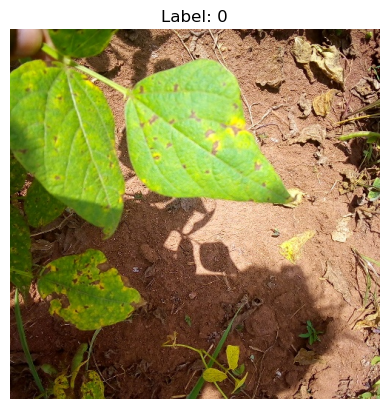

In [78]:
from PIL import Image
import matplotlib.pyplot as plt

# Get one example
example = dataset[0]

# Load image
image = example["image"]

# Display
plt.imshow(image)
plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [64]:
from datasets import load_dataset

dataset = load_dataset("timm/oxford-iiit-pet", split="train[:100]")

df = dataset.to_pandas()
df.head(10)

,image,label,image_id,label_cat_dog
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,20,Maine_Coon_204,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,american_bulldog_138,1
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,18,keeshond_112,1
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,16,havanese_157,1
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,14,german_shorthaired_132,1
5,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3,basset_hound_161,1
6,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,8,boxer_12,1
7,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,22,newfoundland_117,1
8,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,19,leonberger_166,1
9,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,25,pug_123,1


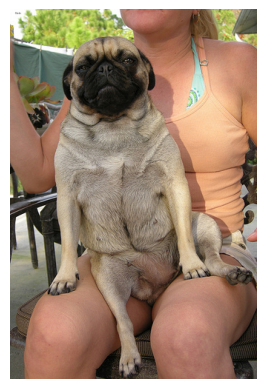

In [66]:
# Get one example
import matplotlib.pyplot as plt
example = dataset[36]

# Load image
image = example["image"]

# Display
plt.imshow(image)
# plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [30]:
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 100
})

In [79]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["label"] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [80]:
dataset = load_dataset("superb", "ks", split="train[:10]")

df = dataset.to_pandas()
df.head()

,file,audio,label
0,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFFXz.\x00WAVEfmt \x10\x00\x00\x0...,10
1,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF*.\x1e\x00WAVEfmt \x10\x00\x00...,10
2,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF0\xe9\x1d\x00WAVEfmt \x10\x00\...,10
3,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF$L\x1d\x00WAVEfmt \x10\x00\x00...,10
4,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF\xe4\xdc\x1d\x00WAVEfmt \x10\x...,10


In [9]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "age": np.random.randint(18, 70, 50),
    "income": np.random.randint(1000, 5000, 50),
    "spending": np.random.randint(100, 2000, 50)
})

df.head()

,age,income,spending
0,31,1694,1992
1,52,4146,1039
2,43,1707,688
3,22,2257,410
4,59,1558,1818


In [90]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:200]")
df = dataset.to_pandas()
df.head()

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

,text
0,
1,= Valkyria Chronicles III = \n
2,
3,Senjō no Valkyria 3 : Unrecorded Chronicles (...
4,"The game began development in 2010 , carrying..."


In [92]:
from datasets import load_dataset

dataset = load_dataset("tweet_eval", "sentiment", split="train[:200]")
df = dataset.to_pandas()

df.head()

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


## Step 2 — Explore (Data Mining)

TODO 1: Display a few examples

TODO 2: What type of data is this?
(text, image, tabular)

TODO 3: Find simple patterns

Examples:
- text: most frequent words
- tabular: average values
- images: visualize samples
etc.

In [23]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "age": np.random.randint(18, 70, 50),
    "income": np.random.randint(1000, 5000, 50),
    "spending": np.random.randint(100, 2000, 50)
})
df.head(10)

,age,income,spending
0,46,3371,1094
1,24,4929,187
2,33,2339,1145
3,48,3686,1176
4,60,4847,1975
5,62,2954,1470
6,43,3294,1444
7,55,4253,1719
8,22,1348,1022
9,57,3066,975


In [22]:
df.corr()

,age,income,spending
age,1.000000,0.076683,0.035187
income,0.076683,1.000000,0.025794
spending,0.035187,0.025794,1.000000


In [25]:
df.mean()

age           44.12
income      3136.86
spending    1078.72
dtype: float64

In [24]:
#Type of data: tabular
#Simple patterns: When income increases, spending is more likely to decrease
#Low correlation - features don't really relate to each other

## Step 3 — Think about labels

### Questions

1. Does this dataset contain labels?
2. If yes:
   - What are they?
3. If no:
   - What could we try to discover?

In [19]:
# This dataset contain no labels
# We can try to discover the groups of people based on their age, income and spending, for example: "Young, high income 
# and high spending", or "Middle-aged, high income and low spending"

## Step 4 — Decide the type of ML

### Identify the problem

- Is this:
  - Data Mining?
  - Supervised Learning?
  - Unsupervised Learning?
  - Reinforcement Learning?

Explain your reasoning.

In [ ]:
# This problem is Unsupervised Learning because the given dataset only includes input values (age, income, spending)
# Without any given label for any of these incomes

## Step 5 — Suggest a task

### Your task

Propose ONE task:

- What is the input (X)?
- What is the output (y)? (if any)
- What is the goal?

Examples:
- classify articles
- cluster customers
- extract entities

In [ ]:
# Input X: age, income, spending; Output: No output

In [ ]:
# Goal: clustering people into 3 groups: high-income and high-spending, high-income and low-spending, low-income and low-spending
# based on each type of people, we can display the suitable type of ads for each (high quality, discount or cheap products)

In [33]:
from sklearn.cluster import KMeans
X = df[['age', 'income', 'spending']]
kmeans = KMeans(n_clusters = 3, random_state = 42)
df['cluster_label'] = kmeans.fit_predict(X)
print(df.head(30))

    age  income  spending  cluster_label
0    46    3371      1094              0
1    24    4929       187              2
2    33    2339      1145              1
3    48    3686      1176              0
4    60    4847      1975              2
5    62    2954      1470              0
6    43    3294      1444              0
7    55    4253      1719              2
8    22    1348      1022              1
9    57    3066       975              0
10   63    4793       585              2
11   22    2449      1481              1
12   21    3631      1228              0
13   32    1872       726              1
14   69    2299       112              1
15   42    1756      1839              1
16   26    3356      1994              0
17   27    4353       818              2
18   34    3427       986              0
19   20    2342      1346              1
20   52    1244       364              1
21   49    4658       319              2
22   64    4737      1943              2
23   65    3161 

In [34]:
print(df.groupby('cluster_label').mean())

                     age       income     spending
cluster_label                                     
0              45.142857  3212.142857  1127.000000
1              38.500000  1733.888889  1080.055556
2              48.944444  4481.277778  1039.833333
